# AIRBNB EDA 03 CREACIÓN DE NUEVAS VARIABLES PARA MODELO    

## IMPORTAR LIBRERÍAS

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## CAMBIAR RUTA A LOCAL Y ABRIR ARCHIVO

In [2]:
os.chdir(r"C:\01. MDA\09. Portfolio")

In [3]:
df = pd.read_csv("listings_clean.csv")

In [4]:
df.head(5)

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,id,name,latitude,longitude,minimum_nights,amenities,last_review,room_type,price,neighbourhood_cleansed,host_id,bedrooms,accommodates,review_scores_rating,review_scores_location,review_scores_checkin
0,0,0,0,3176,Fabulous Flat in great Location,52.53471,13.41810,63,"[""Cooking basics"", ""Wine glasses"", ""Crib"", ""Ho...",2025-08-09,Entire home/apt,105.0,Prenzlauer Berg Südwest,3718,1.0,2,4.63,4.92,4.65
1,1,1,1,9991,Geourgeous flat - outstanding views,52.53269,13.41805,6,"[""Cooking basics"", ""Crib"", ""Stove"", ""Elevator""...",2020-01-04,Entire home/apt,135.0,Prenzlauer Berg Südwest,33852,4.0,7,5.00,4.86,5.00
2,2,2,2,14325,Studio Apartment in Prenzlauer Berg,52.54813,13.40366,150,"[""Ethernet connection"", ""Dishes and silverware...",2023-11-30,Entire home/apt,75.0,Prenzlauer Berg Nordwest,55531,0.0,1,4.68,4.60,4.70
3,3,3,3,17904,Beautiful Kreuzberg studio - 3 months minimum,52.49419,13.42166,93,"[""Cooking basics"", ""Building staff"", ""Essentia...",2025-09-02,Entire home/apt,32.0,Reuterstraße,68997,0.0,2,4.77,4.88,4.89
4,4,4,4,20858,Designer Loft in Berlin Mitte,52.53711,13.40888,3,"[""Cooking basics"", ""Crib"", ""Elevator"", ""High c...",2025-07-16,Entire home/apt,202.0,Prenzlauer Berg Südwest,71331,2.0,4,4.48,4.91,4.50


## Log_Price: VARIABLE OBJETIVO DEL MODELADO

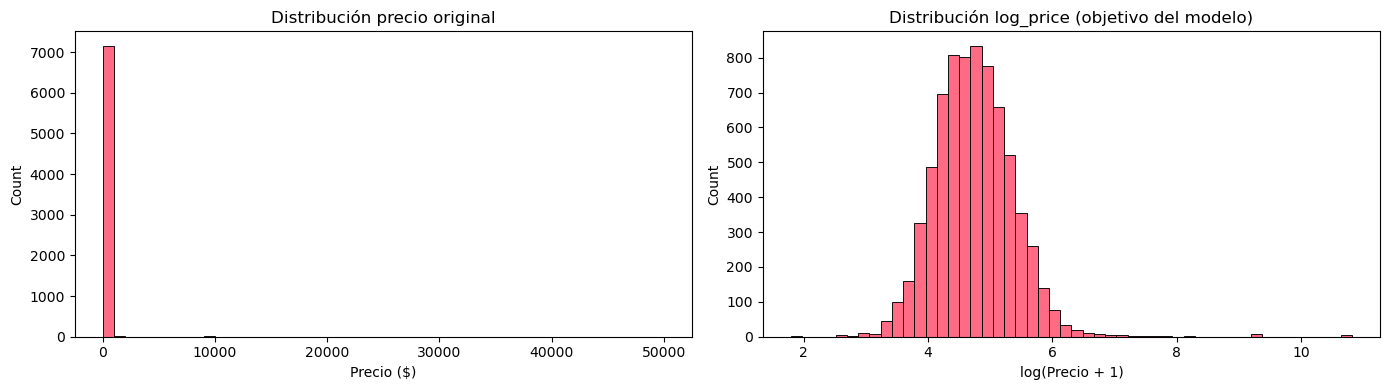

Skewness precio original : 38.34
Skewness log_price       : 1.00


In [5]:
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['price'], bins=50, color='#FF385C', ax=axes[0])
axes[0].set_title('Distribución precio original')
axes[0].set_xlabel('Precio ($)')

sns.histplot(df['log_price'], bins=50, color='#FF385C', ax=axes[1])
axes[1].set_title('Distribución log_price (objetivo del modelo)')
axes[1].set_xlabel('log(Precio + 1)')

plt.tight_layout()
plt.show()

print(f"Skewness precio original : {df['price'].skew():.2f}")
print(f"Skewness log_price       : {df['log_price'].skew():.2f}")

## Price_per_person y Price_per_Bedroom

In [6]:
# Evitar división por cero
df['price_per_person'] = df['price'] / df['accommodates'].replace(0, np.nan)
df['price_per_bedroom'] = df['price'] / df['bedrooms'].replace(0, np.nan)

print('price_per_person:')
print(df['price_per_person'].describe().round(2))
print()
print('price_per_bedroom:')
print(df['price_per_bedroom'].describe().round(2))

price_per_person:
count     7173.00
mean        57.94
std        476.17
min          1.25
25%         27.50
50%         38.20
75%         54.00
max      25000.00
Name: price_per_person, dtype: float64

price_per_bedroom:
count     6672.00
mean       133.65
std       1109.60
min          5.00
25%         62.00
50%         87.00
75%        123.00
max      50000.00
Name: price_per_bedroom, dtype: float64


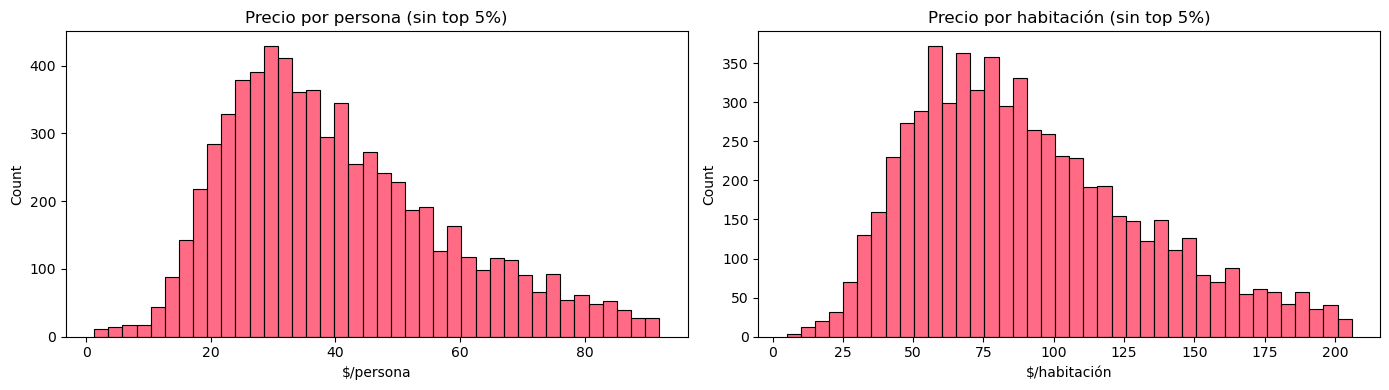

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Filtrar top 5% para visualizar mejor
p95_pp = df['price_per_person'].quantile(0.95)
p95_pb = df['price_per_bedroom'].quantile(0.95)

sns.histplot(df[df['price_per_person'] <= p95_pp]['price_per_person'],
             bins=40, color='#FF385C', ax=axes[0])
axes[0].set_title('Precio por persona (sin top 5%)')
axes[0].set_xlabel('$/persona')

sns.histplot(df[df['price_per_bedroom'] <= p95_pb]['price_per_bedroom'],
             bins=40, color='#FF385C', ax=axes[1])
axes[1].set_title('Precio por habitación (sin top 5%)')
axes[1].set_xlabel('$/habitación')

plt.tight_layout()
plt.show()

## neighbourhood_median_price y neighbourhood_price_rank

In [8]:
neighbourhood_median = df.groupby('neighbourhood_cleansed')['price'].median()
df['neighbourhood_median_price'] = df['neighbourhood_cleansed'].map(neighbourhood_median)

# Ranking: 1 = barrio más barato, N = más caro
rank_map = neighbourhood_median.rank(method='min').astype(int)
df['neighbourhood_price_rank'] = df['neighbourhood_cleansed'].map(rank_map)

print(f"Nº de barrios únicos: {df['neighbourhood_cleansed'].nunique()}")
print()
print('Top 10 barrios más caros (precio mediano):')
print(neighbourhood_median.sort_values(ascending=False).head(10).round(2))

Nº de barrios únicos: 135

Top 10 barrios más caros (precio mediano):
neighbourhood_cleansed
Haselhorst                 237.0
West 5                     226.0
Schmargendorf              172.0
Dammvorstadt               161.0
Tiergarten Süd             158.0
Brunnenstr. Nord           157.0
Prenzlauer Berg Südwest    150.0
Regierungsviertel          150.0
Wiesbadener Straße         148.5
Alexanderplatz             146.0
Name: price, dtype: float64


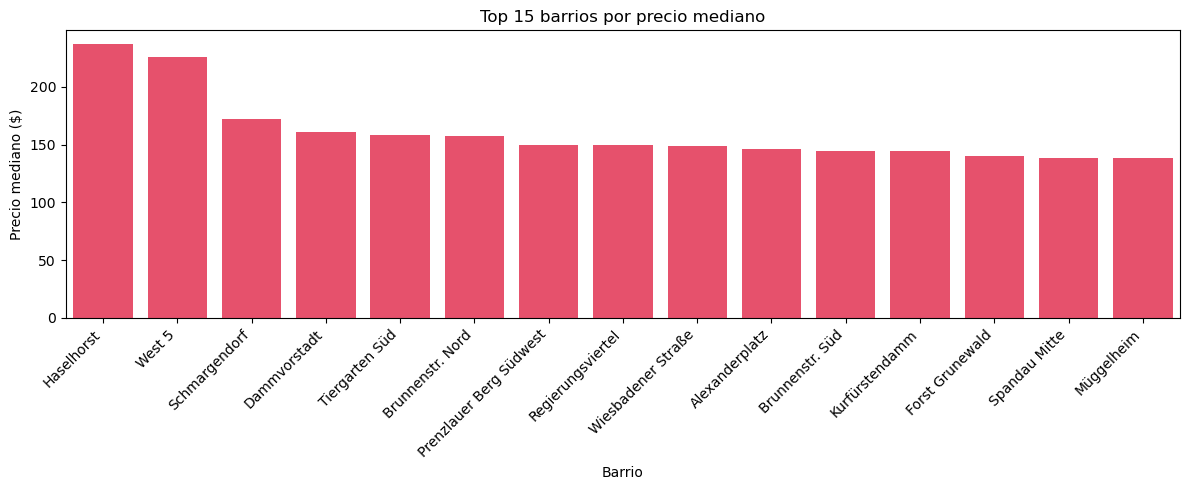

In [9]:
top_barrios = neighbourhood_median.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_barrios.index, y=top_barrios.values, color='#FF385C')
plt.title('Top 15 barrios por precio mediano')
plt.xlabel('Barrio')
plt.ylabel('Precio mediano ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## amenities_count

In [11]:
# Ejemplo del formato raw
print('Ejemplo amenities:')
print(df['amenities'].iloc[0])
print()
print('Tipo:', type(df['amenities'].iloc[0]))

Ejemplo amenities:
["Cooking basics", "Wine glasses", "Crib", "Hot water kettle", "Baking sheet", "Stove", "High chair", "Books and reading material", "Cleaning products", "Patio or balcony", "Heating", "TV", "Bed linens", "Outdoor dining area", "Oven", "Toaster", "Clothing storage", "Fire extinguisher", "Kitchen", "Host greets you", "Iron", "Hot water", "Wifi", "Smoke alarm", "Coffee", "Outdoor furniture", "Essentials", "Ethernet connection", "Coffee maker", "Washer", "First aid kit", "Long term stays allowed", "Extra pillows and blankets", "Dining table", "Dishes and silverware", "Hair dryer", "Children\u2019s dinnerware", "Bathtub", "Hangers", "Freezer", "Carbon monoxide alarm", "Refrigerator", "Private hot tub", "Board games"]

Tipo: <class 'str'>


In [12]:
import ast

def count_amenities(x):
    try:
        return len(ast.literal_eval(x))
    except Exception:
        # Si no es una lista válida, contar por comas como fallback
        return len(str(x).split(','))

df['amenities_count'] = df['amenities'].apply(count_amenities)

print(df['amenities_count'].describe().round(2))

count    7173.00
mean       32.81
std        13.93
min         0.00
25%        23.00
50%        33.00
75%        42.00
max        85.00
Name: amenities_count, dtype: float64


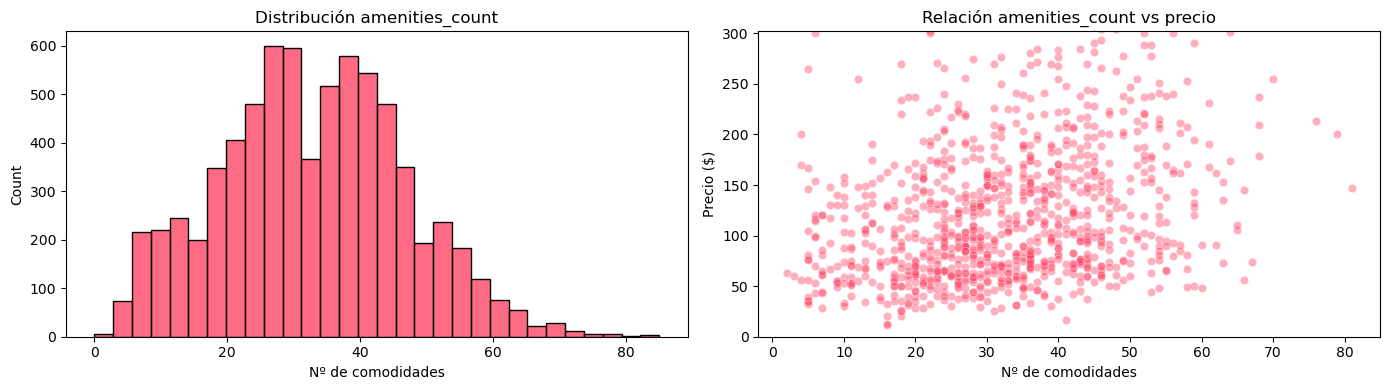

Correlación amenities_count vs price: -0.008


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['amenities_count'], bins=30, color='#FF385C', ax=axes[0])
axes[0].set_title('Distribución amenities_count')
axes[0].set_xlabel('Nº de comodidades')

sns.scatterplot(data=df.sample(1000, random_state=42),
                x='amenities_count', y='price', alpha=0.4, color='#FF385C', ax=axes[1])
axes[1].set_title('Relación amenities_count vs precio')
axes[1].set_xlabel('Nº de comodidades')
axes[1].set_ylabel('Precio ($)')
axes[1].set_ylim(0, df['price'].quantile(0.95))

plt.tight_layout()
plt.show()

print(f"Correlación amenities_count vs price: {df['amenities_count'].corr(df['price']):.3f}")

## days_since_last_review

In [14]:
# Convertir a datetime si no lo está ya
df['last_review'] = pd.to_datetime(df['last_review'])

# Fecha de referencia: última review del dataset (no usamos 'hoy' para reproducibilidad)
fecha_ref = df['last_review'].max()
df['days_since_last_review'] = (fecha_ref - df['last_review']).dt.days

print(f'Fecha de referencia usada: {fecha_ref.date()}')
print()
print(df['days_since_last_review'].describe().round(1))

Fecha de referencia usada: 2025-09-23

count    7173.0
mean      195.0
std       458.1
min         0.0
25%         9.0
50%        25.0
75%       109.0
max      4825.0
Name: days_since_last_review, dtype: float64


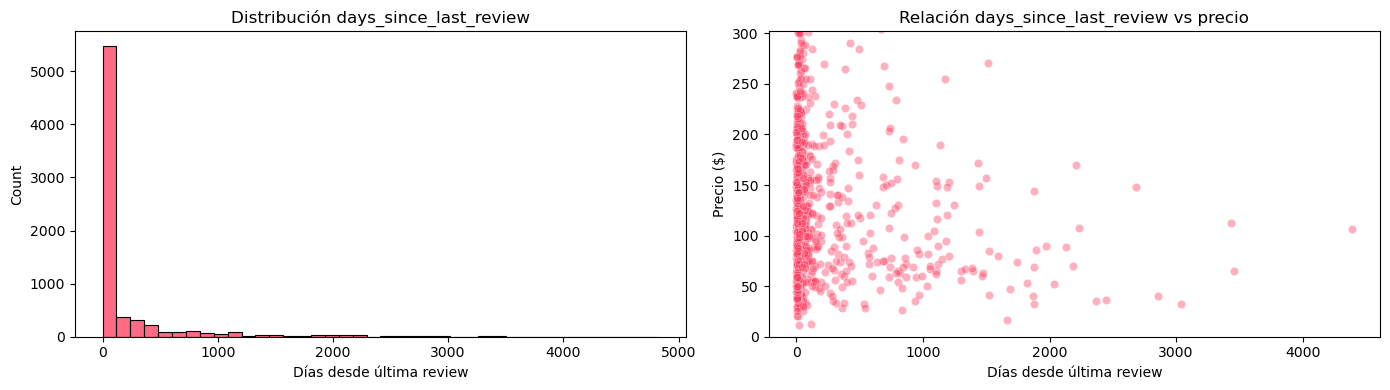

Correlación days_since_last_review vs price: 0.004


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['days_since_last_review'], bins=40, color='#FF385C', ax=axes[0])
axes[0].set_title('Distribución days_since_last_review')
axes[0].set_xlabel('Días desde última review')

sns.scatterplot(data=df.sample(1000, random_state=42),
                x='days_since_last_review', y='price', alpha=0.4, color='#FF385C', ax=axes[1])
axes[1].set_title('Relación days_since_last_review vs precio')
axes[1].set_xlabel('Días desde última review')
axes[1].set_ylabel('Precio ($)')
axes[1].set_ylim(0, df['price'].quantile(0.95))

plt.tight_layout()
plt.show()

print(f"Correlación days_since_last_review vs price: {df['days_since_last_review'].corr(df['price']):.3f}")

## is_entire_home

In [16]:
df['is_entire_home'] = (df['room_type'] == 'Entire home/apt').astype(int)

print('Distribución:')
print(df['is_entire_home'].value_counts())
print()
print('Precio medio por tipo:')
print(df.groupby('is_entire_home')['price'].agg(['mean', 'median']).round(2))

Distribución:
is_entire_home
1    5180
0    1993
Name: count, dtype: int64

Precio medio por tipo:
                  mean  median
is_entire_home                
0               191.21    69.0
1               166.20   127.0


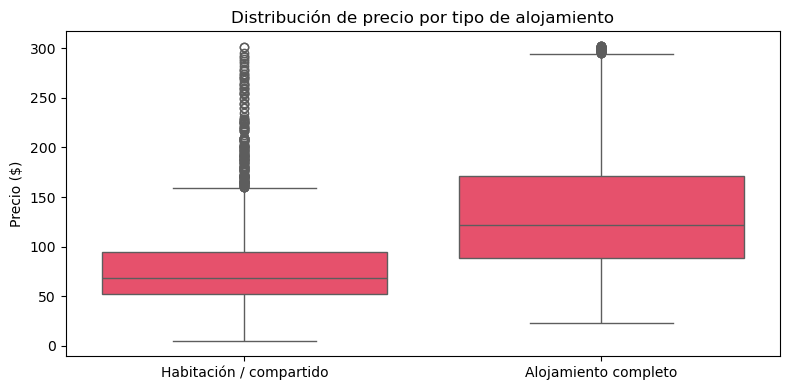

In [17]:
plt.figure(figsize=(8, 4))
p95 = df['price'].quantile(0.95)
sns.boxplot(data=df[df['price'] <= p95], x='is_entire_home', y='price', color='#FF385C')
plt.xticks([0, 1], ['Habitación / compartido', 'Alojamiento completo'])
plt.title('Distribución de precio por tipo de alojamiento')
plt.xlabel('')
plt.ylabel('Precio ($)')
plt.tight_layout()
plt.show()

## RESUMEN VARIABLES CREADAS

In [18]:
new_vars = ['log_price', 'price_per_person', 'price_per_bedroom',
            'neighbourhood_median_price', 'neighbourhood_price_rank',
            'amenities_count', 'days_since_last_review', 'is_entire_home']

print('Nuevas variables creadas:')
print(df[new_vars].describe().round(2))

Nuevas variables creadas:
       log_price  price_per_person  price_per_bedroom  \
count    7173.00           7173.00            6672.00   
mean        4.73             57.94             133.65   
std         0.63            476.17            1109.60   
min         1.79              1.25               5.00   
25%         4.30             27.50              62.00   
50%         4.71             38.20              87.00   
75%         5.12             54.00             123.00   
max        10.82          25000.00           50000.00   

       neighbourhood_median_price  neighbourhood_price_rank  amenities_count  \
count                     7173.00                   7173.00          7173.00   
mean                       112.58                     88.95            32.81   
std                         24.91                     31.16            13.93   
min                         22.00                      1.00             0.00   
25%                         97.00                     67.00 

## CORRELACION CON PRECIO

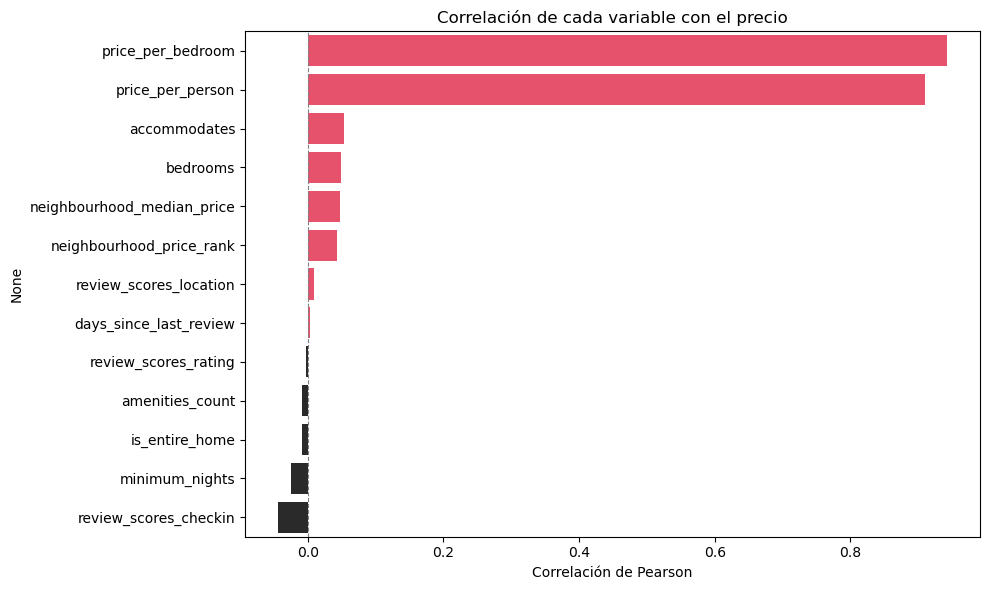

price_per_bedroom             0.942
price_per_person              0.911
accommodates                  0.054
bedrooms                      0.049
neighbourhood_median_price    0.048
neighbourhood_price_rank      0.042
review_scores_location        0.009
days_since_last_review        0.004
review_scores_rating         -0.003
amenities_count              -0.008
is_entire_home               -0.009
minimum_nights               -0.025
review_scores_checkin        -0.043
Name: price, dtype: float64


In [19]:
feature_cols = [
    'accommodates', 'bedrooms', 'minimum_nights',
    'review_scores_rating', 'review_scores_location', 'review_scores_checkin',
    'price_per_person', 'price_per_bedroom', 'neighbourhood_median_price',
    'neighbourhood_price_rank', 'amenities_count', 'days_since_last_review', 'is_entire_home'
]

corr_price = df[feature_cols + ['price']].corr()['price'].drop('price').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#FF385C' if c >= 0 else '#2a2a2a' for c in corr_price.values]
sns.barplot(x=corr_price.values, y=corr_price.index, palette=colors)
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Correlación de cada variable con el precio')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print(corr_price.round(3))

## HEATMAP COMPLETO

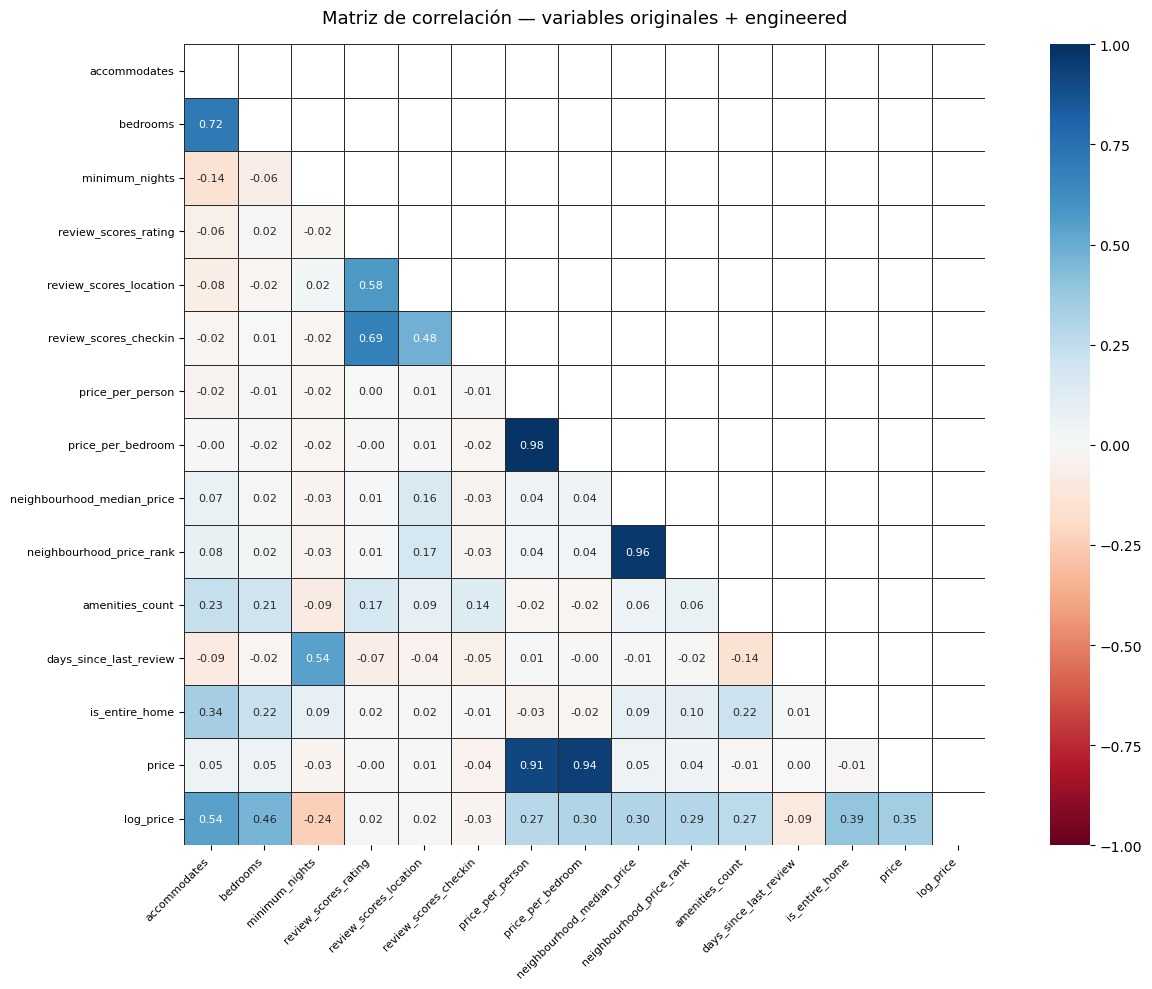

In [21]:
cols_heatmap = feature_cols + ['price', 'log_price']
corr_matrix = df[cols_heatmap].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu', center=0, vmin=-1, vmax=1,
    annot_kws={'size': 8}, linewidths=0.5, linecolor='#2a2a2a',
    square=True, ax=ax
)
ax.set_title('Matriz de correlación — variables originales + engineered', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## IMPORTAR CSV FINAL

In [22]:
df.to_csv('listings_features.csv', index=False)
print(f'Dataset exportado: listings_features.csv')
print(f'Shape final: {df.shape}')
print(f'Columnas totales: {list(df.columns)}')

Dataset exportado: listings_features.csv
Shape final: (7173, 27)
Columnas totales: ['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'id', 'name', 'latitude', 'longitude', 'minimum_nights', 'amenities', 'last_review', 'room_type', 'price', 'neighbourhood_cleansed', 'host_id', 'bedrooms', 'accommodates', 'review_scores_rating', 'review_scores_location', 'review_scores_checkin', 'log_price', 'price_per_person', 'price_per_bedroom', 'neighbourhood_median_price', 'neighbourhood_price_rank', 'amenities_count', 'days_since_last_review', 'is_entire_home']
